# Feature Selection

### Setup

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Setup working directory
from pathlib import Path
import os

def find_root_dir(marker='tfg'):
    p = Path.cwd()
    for candidate in [p] + list(p.parents):
        if candidate.name == marker:
            return candidate.resolve()
        if (candidate / marker).is_dir():
            return (candidate / marker).resolve()
    raise FileNotFoundError(f"Could not find '{marker}' folder in {Path.cwd()} or its parents.")

os.chdir(find_root_dir('tfg'))

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Searborn style (background color, grid, axes, etc.) 
sns.set_style("whitegrid")

# Default values and styling for all plots
plt.rcParams.update({
    "figure.autolayout": True,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})
plt.rcParams["axes.grid"] = False

# Define custom colors
colors = ['crimson', 'lime']
palette = {
        'BENIGN': 'lime',
        'DDoS': 'crimson'
}

In [4]:
traffic_feature_groups = {
    "Traffic Volume Features": [
        "Total Fwd Packets",
        "Total Backward Packets",
        "Total Length of Fwd Packets",
        "Total Length of Bwd Packets",
        "Subflow Fwd Packets",
        "Subflow Fwd Bytes",
        "Subflow Bwd Packets",
        "Subflow Bwd Bytes"
    ],
    "Packet Size Distribution Features": [
        "Fwd Packet Length Max",
        "Fwd Packet Length Min",
        "Fwd Packet Length Mean",
        "Fwd Packet Length Std",
        "Bwd Packet Length Max",
        "Bwd Packet Length Min",
        "Bwd Packet Length Mean",
        "Bwd Packet Length Std",
        "Min Packet Length",
        "Max Packet Length",
        "Packet Length Mean",
        "Packet Length Std",
        "Packet Length Variance",
        "Average Packet Size",
        "Avg Fwd Segment Size",
        "Avg Bwd Segment Size"
    ],
    "Time-related Features": [
        "Flow Duration",
        "Flow IAT Mean",
        "Flow IAT Std",
        "Flow IAT Max",
        "Flow IAT Min",
        "Fwd IAT Total",
        "Fwd IAT Mean",
        "Fwd IAT Std",
        "Fwd IAT Max",
        "Fwd IAT Min",
        "Bwd IAT Total",
        "Bwd IAT Mean",
        "Bwd IAT Std",
        "Bwd IAT Max",
        "Bwd IAT Min",
        "Active Mean",
        "Active Std",
        "Active Max",
        "Active Min",
        "Idle Mean",
        "Idle Std",
        "Idle Max",
        "Idle Min"
    ],
    "Traffic Rate Features": [
        "Flow Bytes/s",
        "Flow Packets/s",
        "Fwd Packets/s",
        "Bwd Packets/s"
    ],
    "TCP Flag Features": [
        "FIN Flag Count",
        "SYN Flag Count",
        "RST Flag Count",
        "PSH Flag Count",
        "ACK Flag Count",
        "URG Flag Count",
        "CWE Flag Count",
        "ECE Flag Count",
        "Fwd PSH Flags",
        "Bwd PSH Flags",
        "Fwd URG Flags",
        "Bwd URG Flags"
    ],
    "Header Features": [
        "Fwd Header Length",
        "Bwd Header Length",
        "Fwd Header Length.1"
    ],
    "Bulk Transfer Features": [
        "Fwd Avg Bytes/Bulk",
        "Fwd Avg Packets/Bulk",
        "Fwd Avg Bulk Rate",
        "Bwd Avg Bytes/Bulk",
        "Bwd Avg Packets/Bulk",
        "Bwd Avg Bulk Rate"
    ],
    "TCP Window Features": [
        "Init_Win_bytes_forward",
        "Init_Win_bytes_backward"
    ],
    "Connection Features": [
        "Down/Up Ratio",
        "act_data_pkt_fwd",
        "min_seg_size_forward"
    ]
}

## Load Data

In [5]:
FILTERED_DATASET_PATH = "data/processed/stage2/full-225k-filtered.parquet"

In [6]:
from src.preprocessing import load_dataset
df = load_dataset(FILTERED_DATASET_PATH)
print("\nBasic Data Information:")
df.info()
print("\nFirst few rows:")
df.head()


Basic Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225603 entries, 0 to 225602
Data columns (total 60 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Flow Duration                225603 non-null  int32  
 1   Total Fwd Packets            225603 non-null  int16  
 2   Total Backward Packets       225603 non-null  int16  
 3   Total Length of Fwd Packets  225603 non-null  int32  
 4   Total Length of Bwd Packets  225603 non-null  int32  
 5   Fwd Packet Length Max        225603 non-null  int16  
 6   Fwd Packet Length Min        225603 non-null  int16  
 7   Fwd Packet Length Mean       225603 non-null  float32
 8   Fwd Packet Length Std        225603 non-null  float32
 9   Bwd Packet Length Max        225603 non-null  int16  
 10  Bwd Packet Length Min        225603 non-null  int16  
 11  Bwd Packet Length Mean       225603 non-null  float32
 12  Bwd Packet Length Std        2256

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Subflow Bwd Bytes,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Label
0,3,2,0,12,0,6,6,6.0,0.0,0,...,0,1,20,0.0,0,0,0.0,0,0,BENIGN
1,109,1,1,6,6,6,6,6.0,0.0,6,...,6,0,20,0.0,0,0,0.0,0,0,BENIGN
2,52,1,1,6,6,6,6,6.0,0.0,6,...,6,0,20,0.0,0,0,0.0,0,0,BENIGN
3,34,1,1,6,6,6,6,6.0,0.0,6,...,6,0,20,0.0,0,0,0.0,0,0,BENIGN
4,3,2,0,12,0,6,6,6.0,0.0,0,...,0,1,20,0.0,0,0,0.0,0,0,BENIGN


## Data Partitioning
- Split data to avoid **data leakage**
- Not necessary to encode target for feature selection
- Keep same ``random_state`` value for **training**

In [7]:
from src.preprocessing import split_features_target
from src.train import split_data

TARGET_COLUMN = "Label"
SEED = 42
X, y = split_features_target(df, TARGET_COLUMN)
X_train, y_train, X_test, y_test = split_data(X,y,test_size=0.2, random_state=SEED)

## Experimental Selection

Correlation analysis conducted on the structurally filtered representation before applying feature transformations. Its purpose was to identify redundant information and define candidate feature subsets based on both statistical relationships and semantic similarity. Allowing the effect of the logarithmic transformation to be evaluated **independently** from the effect of feature selection.

---

Correlation Analysis


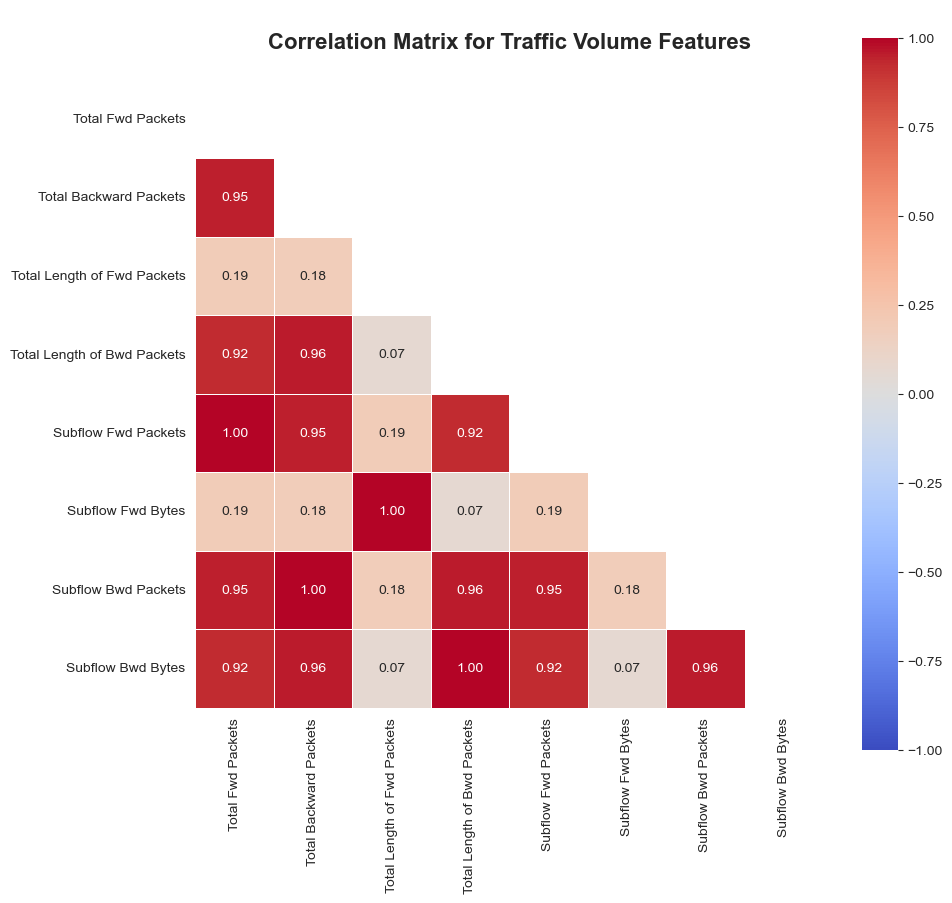

  - Total Fwd Packets <--> Subflow Fwd Packets: r = 1.000
  - Total Length of Fwd Packets <--> Subflow Fwd Bytes: r = 1.000
  - Total Backward Packets <--> Subflow Bwd Packets: r = 1.000
  - Total Length of Bwd Packets <--> Subflow Bwd Bytes: r = 1.000


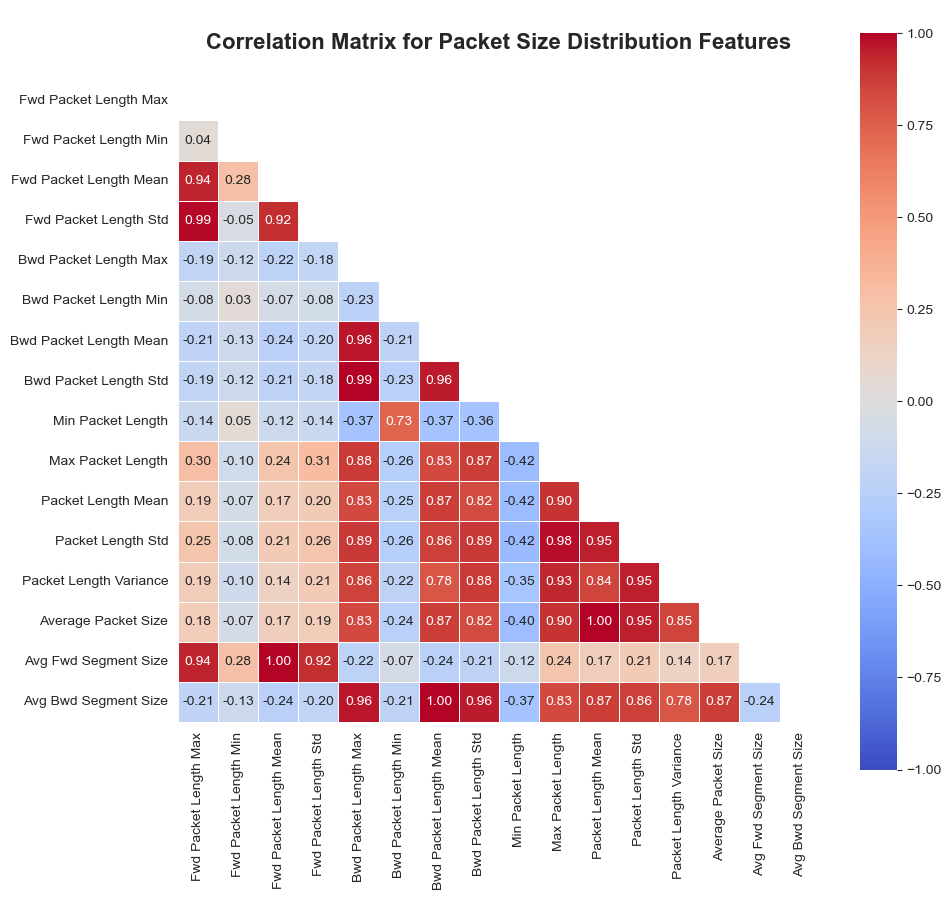

  - Fwd Packet Length Max <--> Fwd Packet Length Std: r = 0.992
  - Bwd Packet Length Max <--> Bwd Packet Length Std: r = 0.993
  - Max Packet Length <--> Packet Length Std: r = 0.984
  - Packet Length Mean <--> Average Packet Size: r = 0.999
  - Fwd Packet Length Mean <--> Avg Fwd Segment Size: r = 1.000
  - Bwd Packet Length Mean <--> Avg Bwd Segment Size: r = 1.000


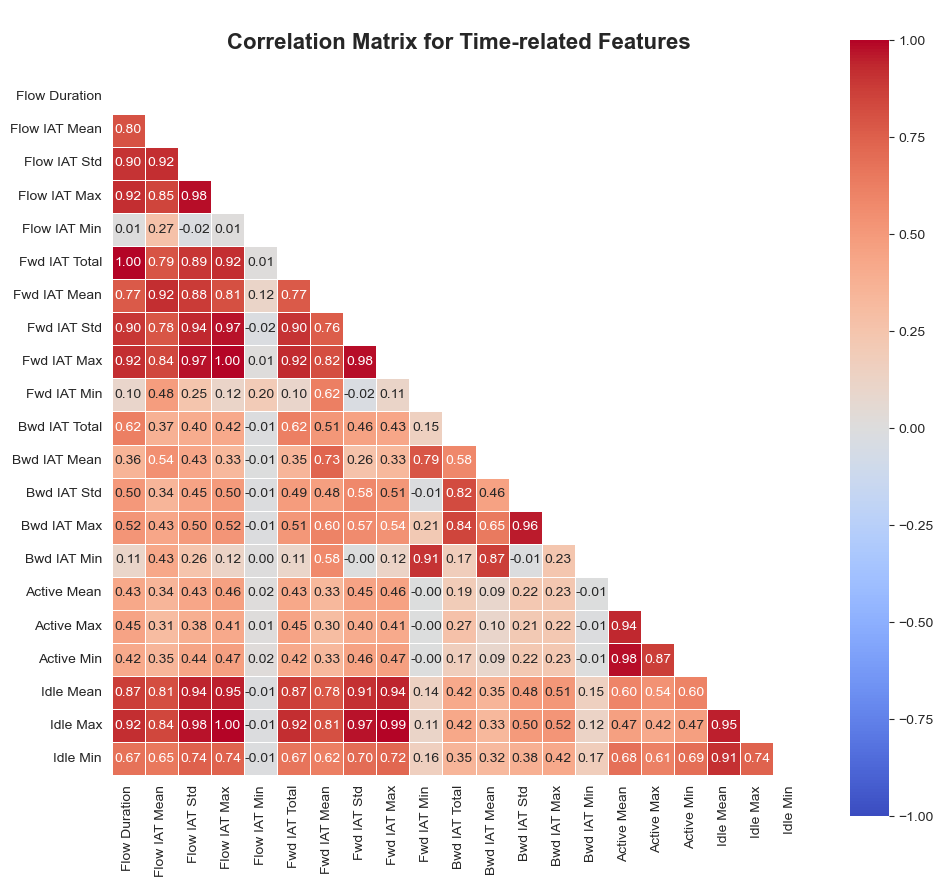

  - Flow Duration <--> Fwd IAT Total: r = 0.997
  - Flow IAT Max <--> Fwd IAT Max: r = 0.995
  - Fwd IAT Std <--> Fwd IAT Max: r = 0.980
  - Active Mean <--> Active Min: r = 0.983
  - Flow IAT Max <--> Idle Max: r = 0.997
  - Fwd IAT Max <--> Idle Max: r = 0.993


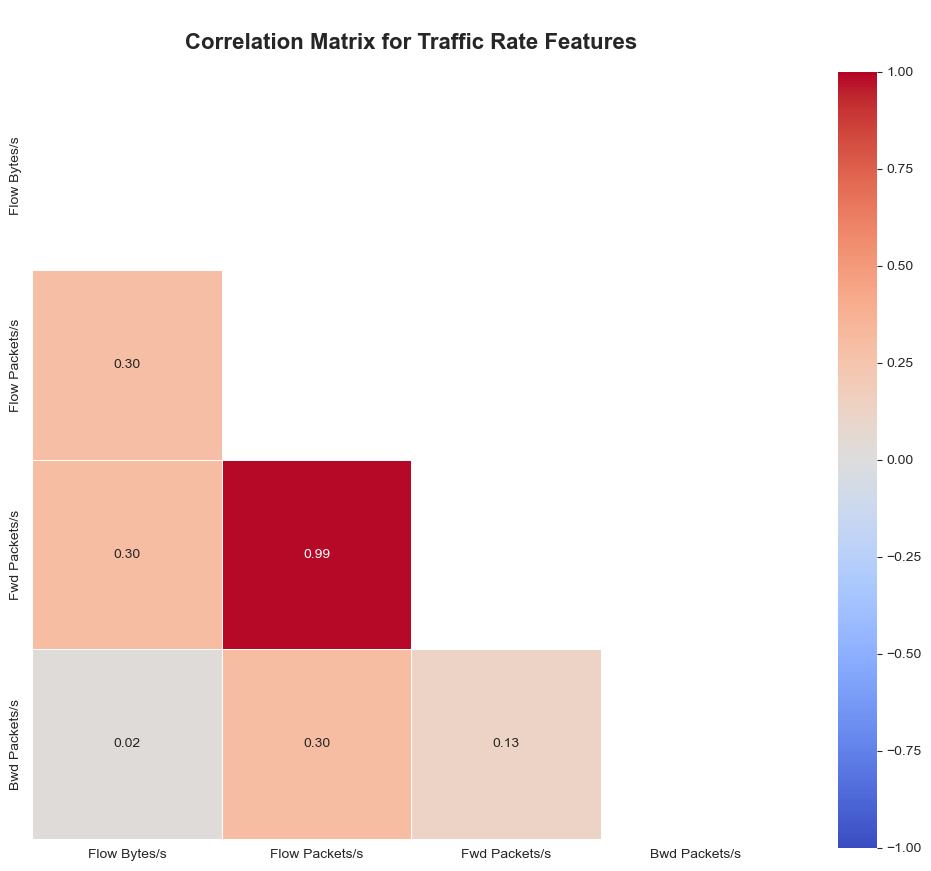

  - Flow Packets/s <--> Fwd Packets/s: r = 0.985


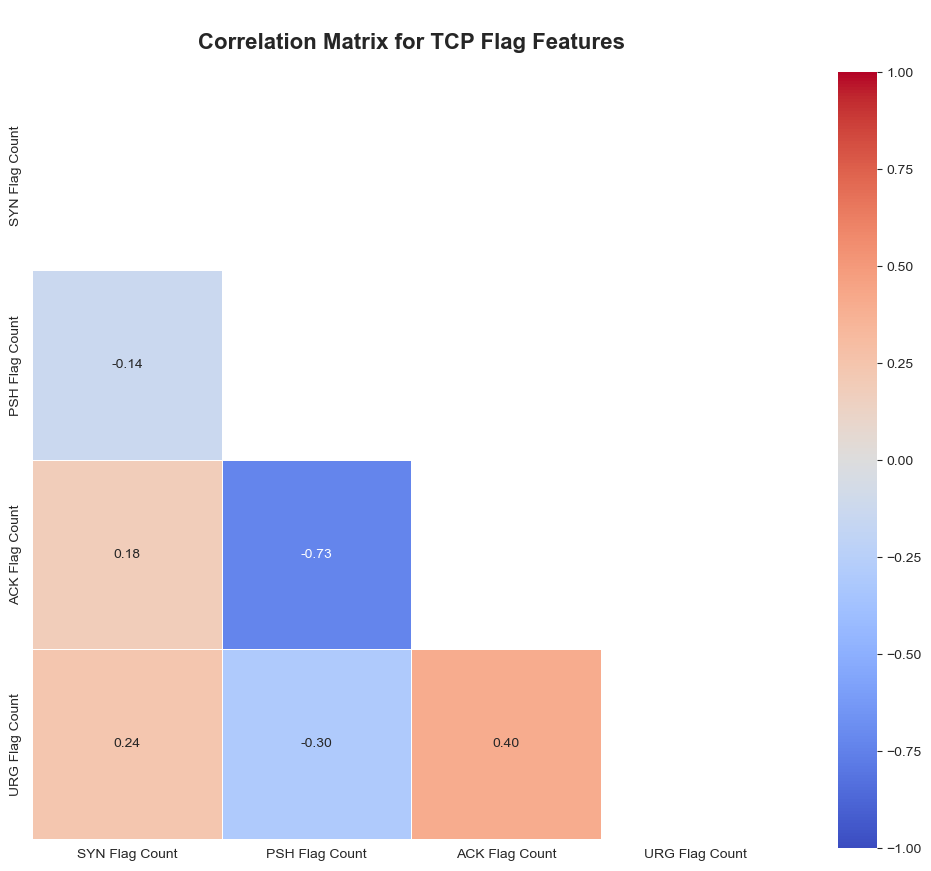

No feature pairs with |r| ≥ 0.98


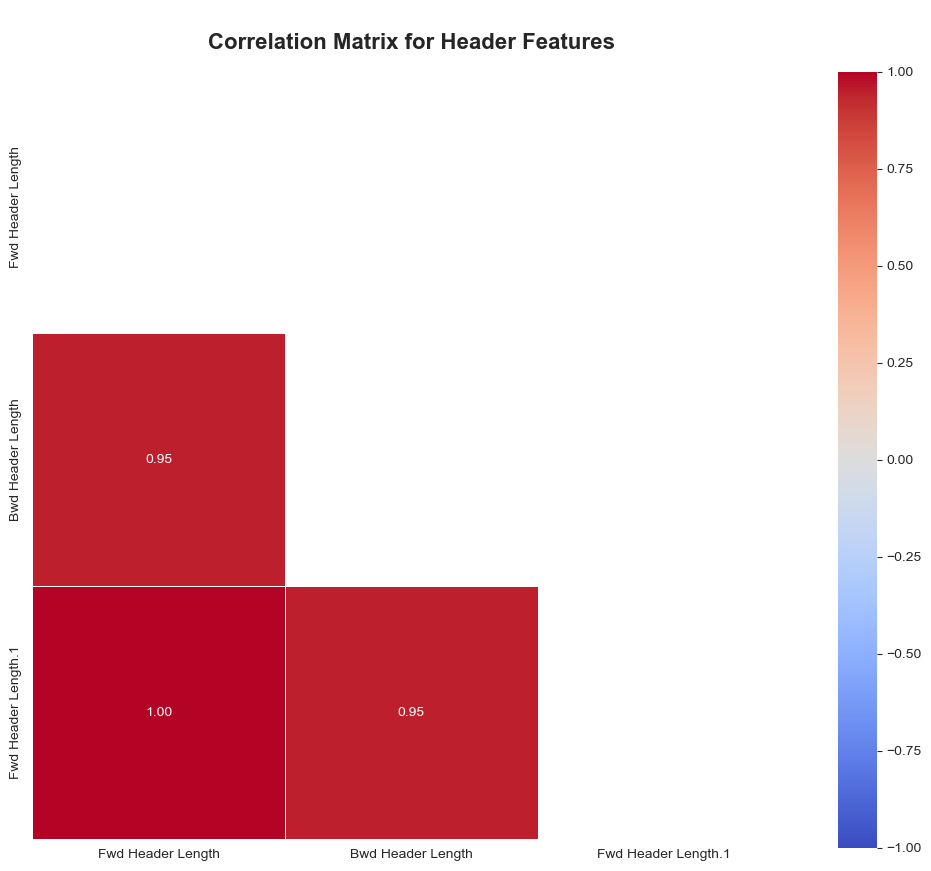

  - Fwd Header Length <--> Fwd Header Length.1: r = 1.000


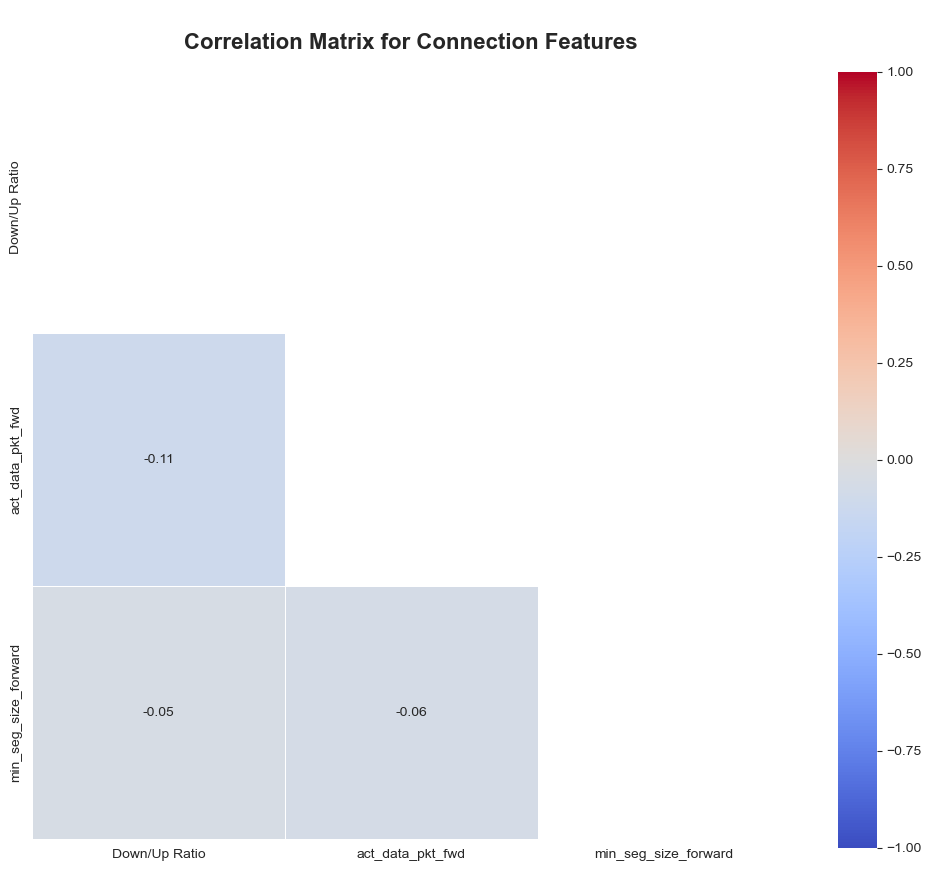

No feature pairs with |r| ≥ 0.98


In [8]:
import numpy as np
from src.utils import intro

def correlation_analysis(df, features_groups, threshold):
    if features_groups is None:
            raise ValueError("features_groups or target is None. Please provide valid values for both parameters.") 
    intro(f"Correlation Analysis")

    # Avoid modifying original data
    data = df.copy()
    for group_name, features in features_groups.items():
        # Keep only existing features
        valid_features = [f for f in features if f in data.columns]
        # Skip empty feature sets
        if len(valid_features) < 2:
            continue
        corr_df = data[valid_features]
        corr_matrix = corr_df.corr(method="pearson")         # Pearson Correlation Matrix 
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # Generate a mask for the upper triangle
        plt.figure(figsize=(10, 10))
        sns.heatmap(
            corr_matrix,
            mask=mask,
            cmap="coolwarm",
            annot=True,
            fmt=".2f",
            linewidth=.5,
            square=True,
            cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1
        )
        plt.title(f"\nCorrelation Matrix for {group_name}\n", fontsize=16, fontweight='bold')
        plt.show()
        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        found = False
        for col in upper.columns:
            correlated = upper.index[upper[col].abs() >= threshold].tolist()
            for row in correlated:
                found = True
                print(f"  - {row} <--> {col}: r = {upper.loc[row, col]:.3f}")
        if not found:
            print(f"No feature pairs with |r| ≥ {threshold}")

correlation_analysis(X_train, traffic_feature_groups, 0.98)

In [9]:
subflow_to_exclude = ['Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes']
packet_size_to_exclude = ['Fwd Packet Length Max', 'Bwd Packet Length Max', 'Packet Length Std', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size']
time_related_to_exclude = ['Fwd IAT Total','Fwd IAT Max','Active Min','Idle Max',]
traffic_rate_to_exclude = ['Fwd Packets/s']
header_to_exclude = ['Fwd Header Length.1']
features_to_exclude = (
    subflow_to_exclude
    + packet_size_to_exclude
    + time_related_to_exclude
    + traffic_rate_to_exclude
    + header_to_exclude
)
df_feature_selection = df.drop(columns=features_to_exclude)

#### Re-check correlation

Correlation Analysis


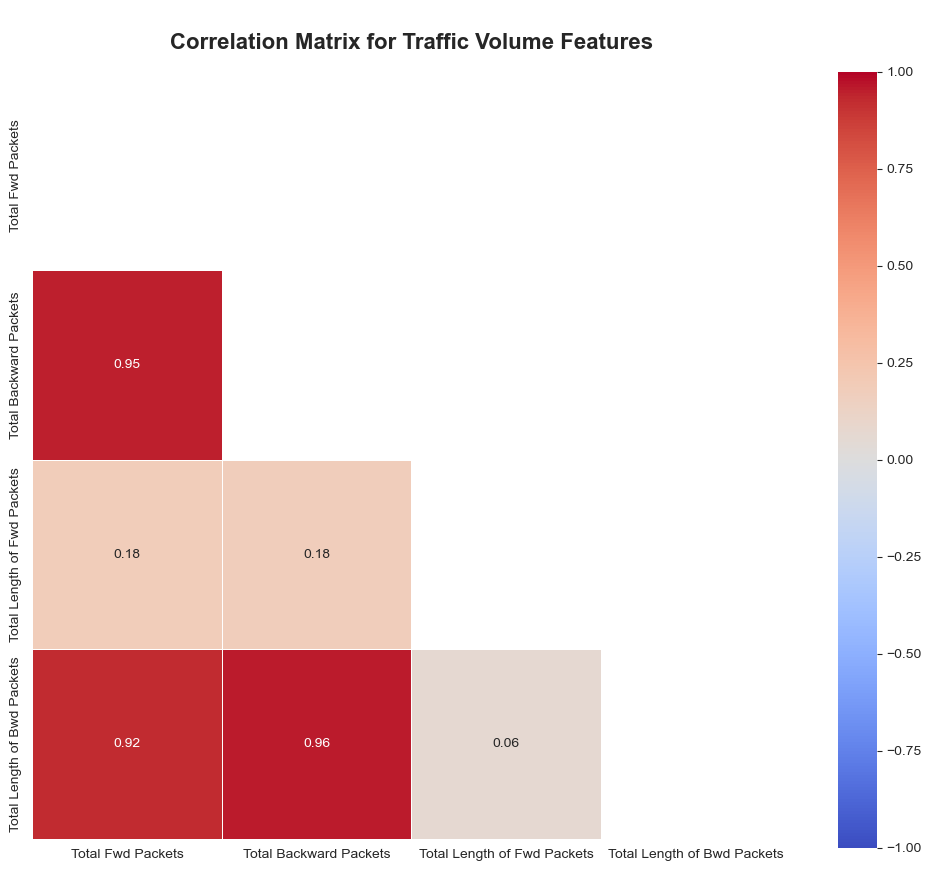

No feature pairs with |r| ≥ 0.98


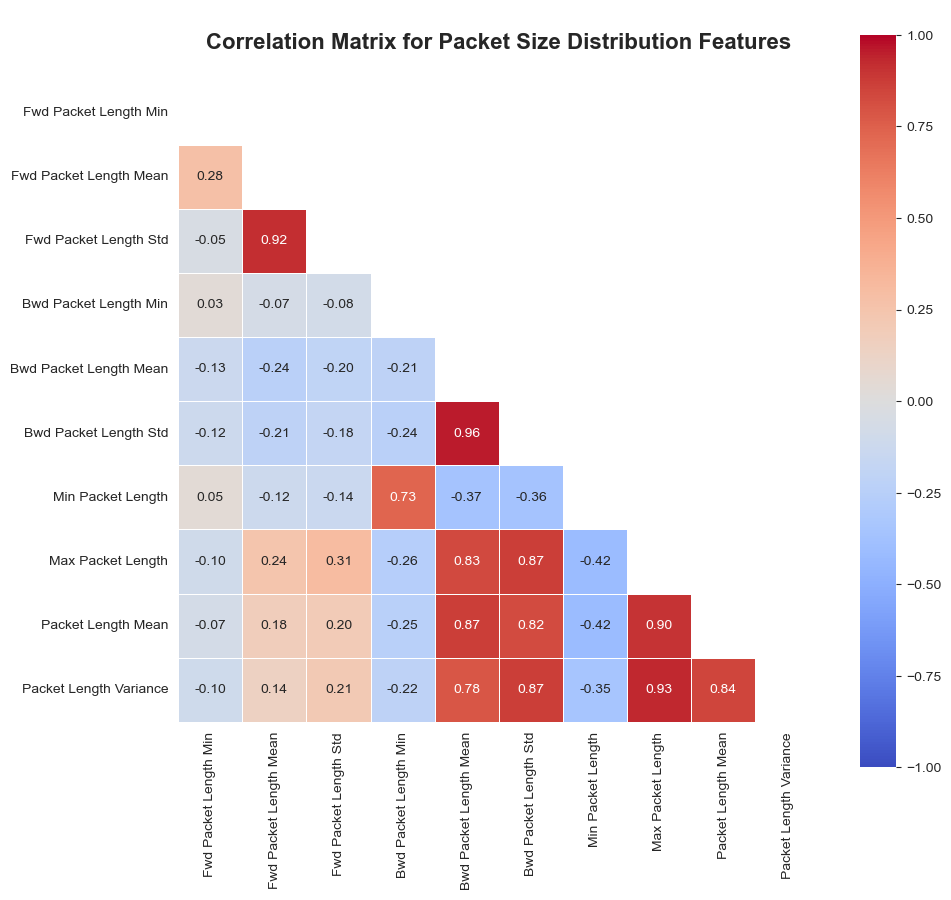

No feature pairs with |r| ≥ 0.98


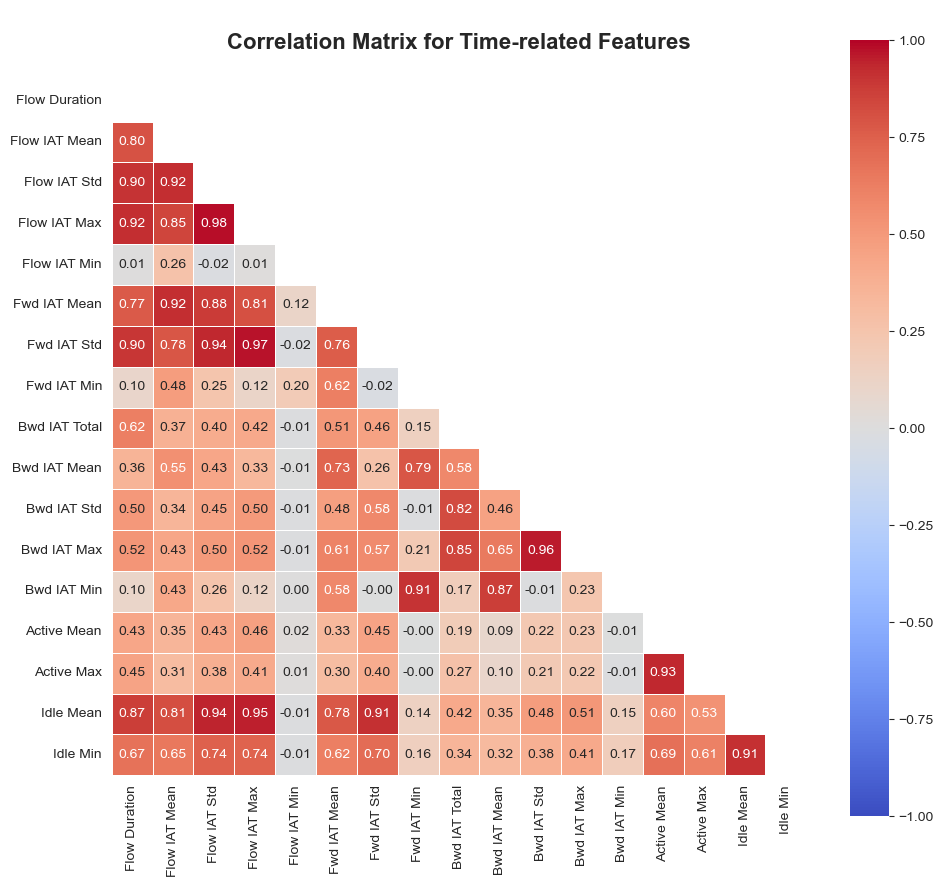

No feature pairs with |r| ≥ 0.98


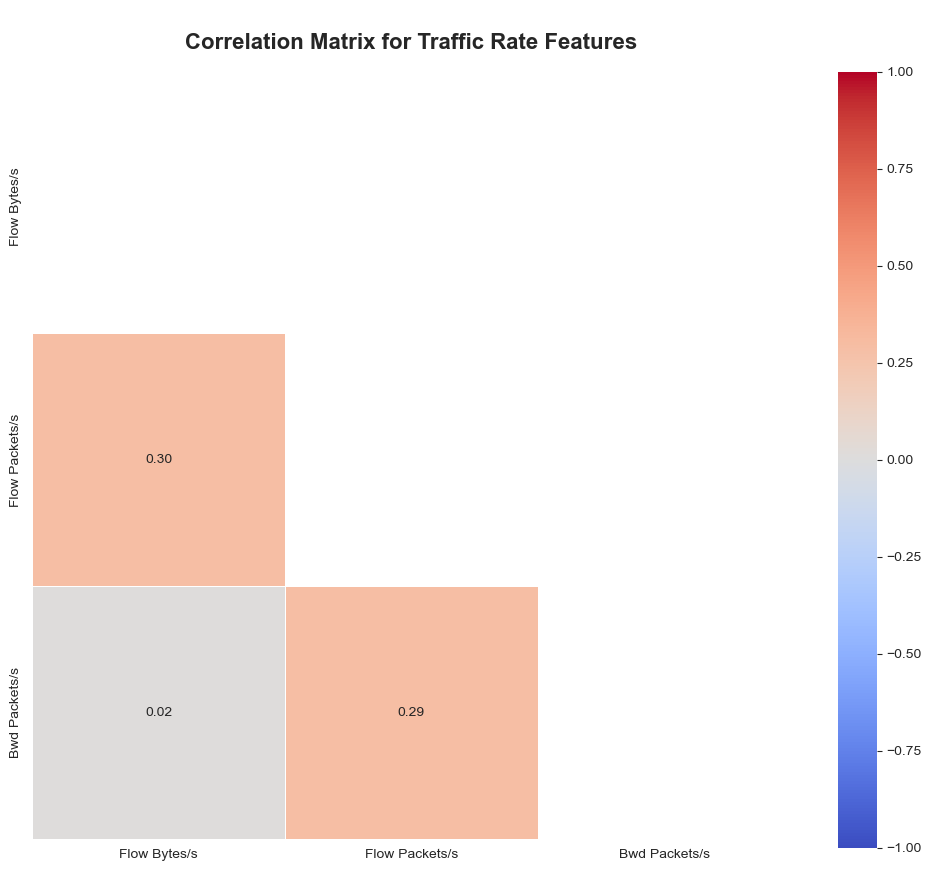

No feature pairs with |r| ≥ 0.98


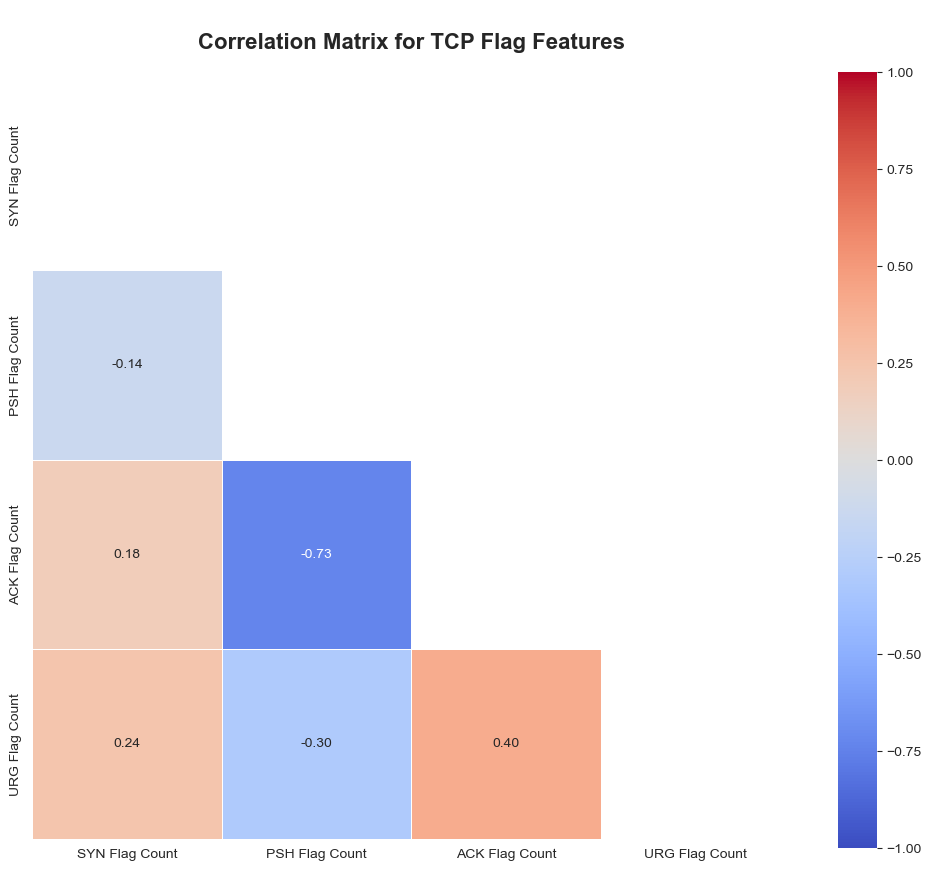

No feature pairs with |r| ≥ 0.98


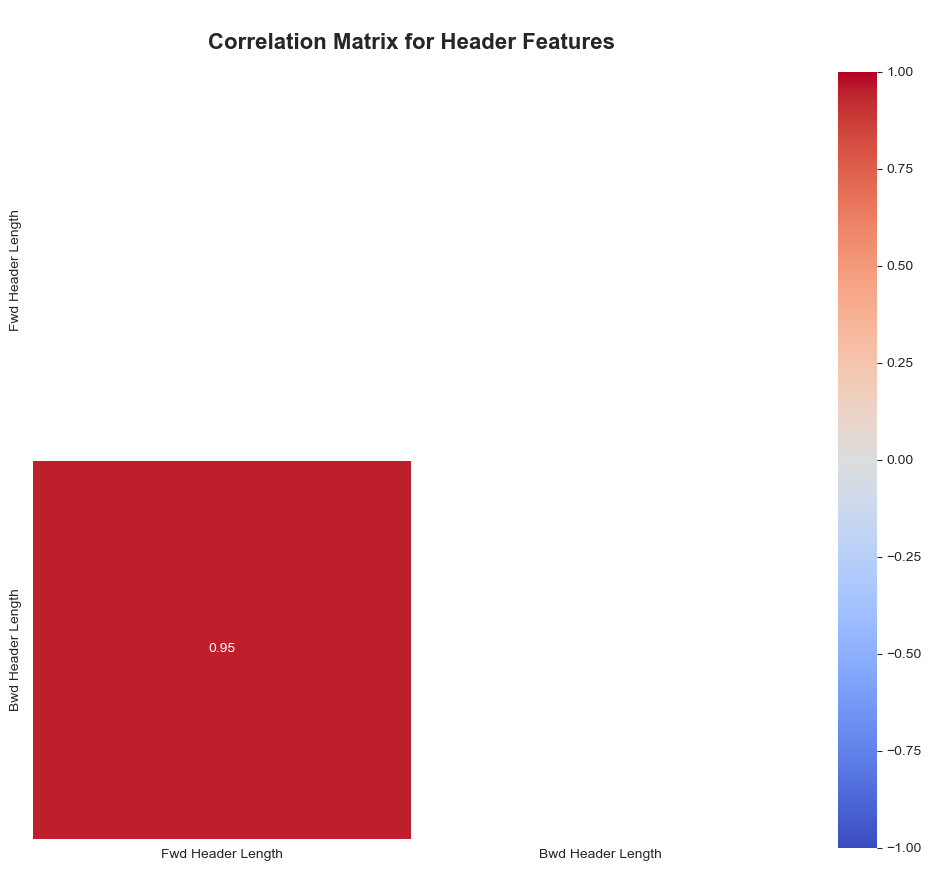

No feature pairs with |r| ≥ 0.98


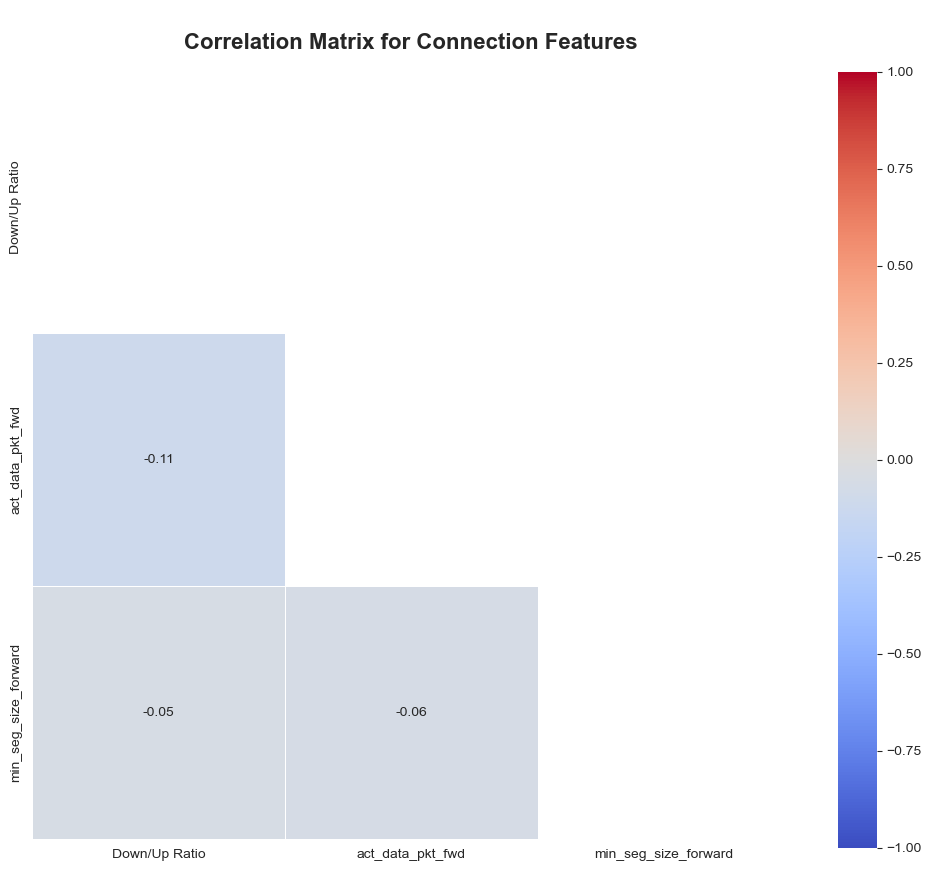

No feature pairs with |r| ≥ 0.98


In [10]:
correlation_analysis(df_feature_selection, traffic_feature_groups, 0.98)

## Save Datasets

In [11]:
from src.preprocessing import save
save("stage2/full-225k-correlation_098.parquet", df_feature_selection)

Saving dataset as .parquet
Final Dataset Saved: data/processed\stage2/full-225k-correlation_098.parquet (18.39 MB) 
